# Drova - Forsaken Kin 출시 후 LLM 리뷰 분석 보고서

## 분석 목적
이미 출시된 게임의 Steam 리뷰와 LLM 분석 결과를 바탕으로,  
개발자가 **현재 유저들이 무엇을 좋아하고 무엇에 불만을 가지는지** 파악하고, **패치·운영 우선순위**를 정하는 것을 목적으로 한다.

## 핵심 질문
1. 현재 이 게임의 출시 후 반응은 긍정적인가, 부정적인가?
2. 유저들은 어떤 요소를 강점으로 보고 있는가?
3. 부정 리뷰에서는 어떤 문제가 반복적으로 나타나는가?
4. 어떤 문제를 먼저 고쳐야 반응 개선 가능성이 높은가?
5. 운영·패치 방향을 어떻게 정리할 수 있는가?

## 사용 데이터
| 파일 | 역할 |
|---|---|
| `llm_review_analysis_result.csv` | 리뷰 1개 단위의 LLM 감성분석 결과 |
| `llm_issue_tags_flat.csv` | 리뷰 안에서 추출된 이슈 태그를 태그 단위로 펼친 결과 |

> 이 보고서는 단순히 감정 분포만 보는 것이 아니라, **좋아한 요소 / 불만 요소 / 긴급도 / 플레이타임 / 출시 후 구간**을 함께 보면서 운영 판단으로 연결한다.


In [1]:
# ============================================================
# 기본 라이브러리
# ============================================================
import os
import ast
import json
import time
import asyncio
import platform
from pathlib import Path
from typing import List, Literal, Optional
from datetime import datetime


# ============================================================
# 데이터 분석용 라이브러리
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ============================================================
# 한글 폰트 설정
# ============================================================
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)


# 1. 설정값

아래 설정값만 바꾸면 다른 게임에도 같은 구조로 보고서를 만들 수 있다.

현재 보고서는 **출시 후 분석**이므로 기본적으로 특정 게임 1개를 대상으로 보는 구조다.  
다만 파일에 여러 게임이 섞여 있으면 `TARGET_APPID` 또는 `TARGET_GAME_NAME`을 지정하면 된다.

둘 다 비워두면 리뷰 수가 가장 많은 게임을 자동 선택한다.


In [2]:
# ============================================================
# 1. 경로 설정
# ============================================================

# 프로젝트 루트 직접 지정
# 다른 환경에서 실행할 경우 ROOT만 본인 프로젝트 경로에 맞게 수정
ROOT = Path(r"C:\Users\joon5\Documents\github\steam-indie-game-analysis")

# LLM 분석 결과 폴더
RUN_NAME = "postlaunch_drova_v1"
OUTPUT_DIR = ROOT / "data" / "outputs" / RUN_NAME

# LLM 분석 산출물
RESULT_PATH = OUTPUT_DIR / "llm_review_analysis_result.csv"
TAG_PATH = OUTPUT_DIR / "llm_issue_tags_flat.csv"


print("ROOT 존재:", ROOT.exists())
print("LLM 감성분석 결과 존재:", RESULT_PATH.exists())
print("LLM 감성분석 태그 존재:", TAG_PATH.exists())

print("\n프로젝트 루트:", ROOT)
print("LLM 감성분석 결과 :", RESULT_PATH)
print("LLM 감성분석 태그:", TAG_PATH)

# ============================================================
# 1-1. 보고서 설정값
# ============================================================

# 분석 대상 게임
TARGET_APPID = 1585180
TARGET_GAME_NAME = "Drova - Forsaken Kin"

# 여러 게임이 들어 있을 때 자동으로 리뷰 수가 가장 많은 게임을 선택할지 여부
AUTO_SELECT_IF_MULTIPLE_GAMES = False

# 보고서에 보여줄 상위 항목 수
TOP_N = 10

# 플레이타임 구간
# 0~1시간: 첫인상/초기 이탈
# 1~5시간: 초반 플레이 경험
# 5~20시간: 중반 플레이 경험
# 20시간 이상: 장기 플레이/누적 불만
PLAYTIME_BINS = [-0.001, 1, 5, 20, np.inf]
PLAYTIME_LABELS = ["0~1시간", "1~5시간", "5~20시간", "20시간 이상"]

# 출시 후 구간 정렬 기준
PERIOD_ORDER = ["D0-D7", "D8-D30", "D0-D30", "D31-D90", "D91-D180", "D181+"]


ROOT 존재: True
LLM 감성분석 결과 존재: True
LLM 감성분석 태그 존재: True

프로젝트 루트: C:\Users\joon5\Documents\github\steam-indie-game-analysis
LLM 감성분석 결과 : C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\postlaunch_drova_v1\llm_review_analysis_result.csv
LLM 감성분석 태그: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\postlaunch_drova_v1\llm_issue_tags_flat.csv


# 2. 데이터 불러오기 및 기본 점검

출시 후 분석에서 핵심이 되는 데이터는 두 가지다.

| 데이터 | 분석 관점 |
|---|---|
| 리뷰 단위 데이터 | 리뷰별 감정, 긴급도, 플레이타임, 출시 후 경과일 |
| 태그 단위 데이터 | 반복되는 칭찬 요인과 불만 요인 |


In [3]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================

df_result_raw = pd.read_csv(RESULT_PATH)
df_tags_raw = pd.read_csv(TAG_PATH)

print("df_result_raw shape:", df_result_raw.shape)
print("df_tags_raw shape:", df_tags_raw.shape)

display(df_result_raw.head(3))
display(df_tags_raw.head(3))


df_result_raw shape: (399, 20)
df_tags_raw shape: (805, 15)


,analysis_status,recommendationid,appid,game_name,review_datetime,release_date,days_from_release,release_period,steam_label_text,playtime_at_review_hours,votes_up,weighted_vote_score,llm_sentiment,sentiment_score,primary_issue,issue_tags,urgency,summary,suggested_action,sentiment_relation
0,success,201691334,1585180,Drova - Forsaken Kin,2025-08-08 08:52:41,2024-10-15,297.0,D181+,negative,0.983333,36.0,0.602359,negative,1.0,story,"[{'category': 'story', 'sentiment': 'negative', 'evidence': 'characters are singular and one-dimensional, dialogue i...",high,대사와 캐릭터의 깊이가 부족하고 퀘스트 설계가 부자연스러워 몰입하기 어렵다는 비판입니다.,"초반부 대사 및 퀘스트 스크립트를 전면 재검토하고, 캐릭터의 동기와 반응이 논리적으로 연결되도록 서사 구조를 보강하세요. 특히 퀘스트 진행 중 플레이어의 행동이 세계관에 미치는 영향력을 더 세밀하게 묘사할 필...",exact_match
1,success,184793757,1585180,Drova - Forsaken Kin,2025-01-05 01:37:52,2024-10-15,82.0,D31-D90,positive,27.016667,0.0,0.500000,positive,5.0,positive_praise,"[{'category': 'positive_praise', 'sentiment': 'positive', 'evidence': ""scratched an itch that hadn't been scratched ...",low,오랜만에 만족스러운 게임 경험을 제공했다는 긍정적인 평가입니다.,"현재의 게임 핵심 재미 요소(RPG 탐험 및 시스템)를 유지하면서, 향후 업데이트나 차기작에서도 유사한 만족감을 줄 수 있는 콘텐츠를 지속적으로 개발하세요.",exact_match
2,success,200636508,1585180,Drova - Forsaken Kin,2025-07-25 02:57:26,2024-10-15,283.0,D181+,negative,33.516667,1.0,0.396259,negative,2.0,gameplay_loop,"[{'category': 'gameplay_loop', 'sentiment': 'negative', 'evidence': 'Unrealistic amounts of roaming for nothing wort...",medium,게임의 과도한 홍보에 비해 실제 탐험의 보상이 부족하고 이동이 지루하다는 평가입니다.,"오픈 월드 탐험 시 보상 체계를 재점검하세요. 이동 거리에 비해 보상이 부족하다는 의견이 있으므로, 주요 거점이나 탐험 지역에 의미 있는 아이템이나 서사적 보상을 배치하여 탐험의 동기를 강화해야 합니다.",exact_match


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence
0,201691334,1585180,Drova - Forsaken Kin,negative,negative,story,high,D181+,0.983333,36.0,0.602359,story,스토리,negative,"characters are singular and one-dimensional, dialogue is awful, prose is sloppy and fake"
1,201691334,1585180,Drova - Forsaken Kin,negative,negative,story,high,D181+,0.983333,36.0,0.602359,gameplay_loop,게임플레이 루프,negative,"Quests are ludicrously hamfisted, quest logic is inconsistent"
2,184793757,1585180,Drova - Forsaken Kin,positive,positive,positive_praise,low,D31-D90,27.016667,0.0,0.500000,positive_praise,긍정 칭찬,positive,scratched an itch that hadn't been scratched in a long time


In [4]:
# ============================================================
# 2-1. 필수 컬럼 확인
# ============================================================

required_result_cols = [
    "recommendationid",
    "appid",
    "game_name",
    "steam_label_text",
    "llm_sentiment",
    "urgency",
    "primary_issue",
    "summary",
    "suggested_action",
]

required_tag_cols = [
    "recommendationid",
    "appid",
    "game_name",
    "tag_category",
    "tag_sentiment",
    "tag_evidence",
]

missing_result_cols = [c for c in required_result_cols if c not in df_result_raw.columns]
missing_tag_cols = [c for c in required_tag_cols if c not in df_tags_raw.columns]

if missing_result_cols:
    raise ValueError(f"df_result에 필요한 컬럼이 없습니다: {missing_result_cols}")

if missing_tag_cols:
    raise ValueError(f"df_tags에 필요한 컬럼이 없습니다: {missing_tag_cols}")

print("필수 컬럼 확인 완료")


필수 컬럼 확인 완료


In [5]:
# ============================================================
# 2-2. 컬럼 표준화 및 파생 컬럼 생성
# ============================================================

df_result = df_result_raw.copy()
df_tags = df_tags_raw.copy()

# ID는 조인 안정성을 위해 문자열로 통일
df_result["recommendationid"] = df_result["recommendationid"].astype(str)
df_tags["recommendationid"] = df_tags["recommendationid"].astype(str)

# 날짜형 변환
for col in ["review_datetime", "release_date"]:
    if col in df_result.columns:
        df_result[col] = pd.to_datetime(df_result[col], errors="coerce")

# 출시 후 경과일 생성
if "days_from_release" not in df_result.columns or df_result["days_from_release"].isna().all():
    if {"review_datetime", "release_date"}.issubset(df_result.columns):
        df_result["days_from_release"] = (df_result["review_datetime"] - df_result["release_date"]).dt.days

# 출시 후 구간 생성
if "release_period" not in df_result.columns:
    df_result["release_period"] = pd.cut(
        df_result["days_from_release"],
        bins=[-1, 7, 30, 90, 180, np.inf],
        labels=["D0-D7", "D8-D30", "D31-D90", "D91-D180", "D181+"]
    ).astype("object")

# 텍스트 라벨 소문자 통일
for col in ["steam_label_text", "llm_sentiment", "urgency", "sentiment_relation"]:
    if col in df_result.columns:
        df_result[col] = df_result[col].astype(str).str.lower().str.strip()

for col in ["steam_label_text", "llm_sentiment", "urgency", "tag_sentiment", "release_period"]:
    if col in df_tags.columns:
        df_tags[col] = df_tags[col].astype(str).str.lower().str.strip()

# release_period는 대문자 형식 유지
if "release_period" in df_result.columns:
    df_result["release_period"] = df_result["release_period"].astype(str).str.upper()
if "release_period" in df_tags.columns:
    df_tags["release_period"] = df_tags["release_period"].astype(str).str.upper()

# 플레이타임 구간 생성
if "playtime_at_review_hours" in df_result.columns:
    df_result["playtime_bin"] = pd.cut(
        df_result["playtime_at_review_hours"],
        bins=PLAYTIME_BINS,
        labels=PLAYTIME_LABELS
    ).astype("object")
else:
    df_result["playtime_bin"] = "정보 없음"

if "playtime_at_review_hours" in df_tags.columns:
    df_tags["playtime_bin"] = pd.cut(
        df_tags["playtime_at_review_hours"],
        bins=PLAYTIME_BINS,
        labels=PLAYTIME_LABELS
    ).astype("object")
else:
    df_tags["playtime_bin"] = "정보 없음"

# 한국어 이슈명 보정
ISSUE_NAME_KOR = {
    "positive_praise": "긍정 칭찬",
    "gameplay_loop": "게임플레이 루프",
    "content_volume": "콘텐츠 분량",
    "control": "조작감",
    "difficulty": "난이도",
    "multiplayer_network": "멀티/네트워크",
    "ui_ux": "UI/UX",
    "bug": "버그",
    "balance": "밸런스",
    "price_value": "가격/가치",
    "crash": "크래시",
    "performance": "성능",
    "other": "기타",
    "graphics_audio": "그래픽/사운드",
    "translation_localization": "번역/현지화",
    "developer_communication": "개발사 소통",
    "progression_grind": "성장/반복 노가다",
    "story": "스토리",
    "optimization": "최적화",
    "monetization": "과금/수익화",
    "save_progression": "저장/진행",
}

if "issue_name_kor" not in df_tags.columns:
    df_tags["issue_name_kor"] = df_tags["tag_category"].map(ISSUE_NAME_KOR).fillna(df_tags["tag_category"])
else:
    df_tags["issue_name_kor"] = df_tags["issue_name_kor"].fillna(df_tags["tag_category"].map(ISSUE_NAME_KOR))

print("전처리 후 데이터 확인")
display(df_result.head(3))
display(df_tags.head(3))


전처리 후 데이터 확인


,analysis_status,recommendationid,appid,game_name,review_datetime,release_date,days_from_release,release_period,steam_label_text,playtime_at_review_hours,votes_up,weighted_vote_score,llm_sentiment,sentiment_score,primary_issue,issue_tags,urgency,summary,suggested_action,sentiment_relation,playtime_bin
0,success,201691334,1585180,Drova - Forsaken Kin,2025-08-08 08:52:41,2024-10-15,297.0,D181+,negative,0.983333,36.0,0.602359,negative,1.0,story,"[{'category': 'story', 'sentiment': 'negative', 'evidence': 'characters are singular and one-dimensional, dialogue i...",high,대사와 캐릭터의 깊이가 부족하고 퀘스트 설계가 부자연스러워 몰입하기 어렵다는 비판입니다.,"초반부 대사 및 퀘스트 스크립트를 전면 재검토하고, 캐릭터의 동기와 반응이 논리적으로 연결되도록 서사 구조를 보강하세요. 특히 퀘스트 진행 중 플레이어의 행동이 세계관에 미치는 영향력을 더 세밀하게 묘사할 필...",exact_match,0~1시간
1,success,184793757,1585180,Drova - Forsaken Kin,2025-01-05 01:37:52,2024-10-15,82.0,D31-D90,positive,27.016667,0.0,0.500000,positive,5.0,positive_praise,"[{'category': 'positive_praise', 'sentiment': 'positive', 'evidence': ""scratched an itch that hadn't been scratched ...",low,오랜만에 만족스러운 게임 경험을 제공했다는 긍정적인 평가입니다.,"현재의 게임 핵심 재미 요소(RPG 탐험 및 시스템)를 유지하면서, 향후 업데이트나 차기작에서도 유사한 만족감을 줄 수 있는 콘텐츠를 지속적으로 개발하세요.",exact_match,20시간 이상
2,success,200636508,1585180,Drova - Forsaken Kin,2025-07-25 02:57:26,2024-10-15,283.0,D181+,negative,33.516667,1.0,0.396259,negative,2.0,gameplay_loop,"[{'category': 'gameplay_loop', 'sentiment': 'negative', 'evidence': 'Unrealistic amounts of roaming for nothing wort...",medium,게임의 과도한 홍보에 비해 실제 탐험의 보상이 부족하고 이동이 지루하다는 평가입니다.,"오픈 월드 탐험 시 보상 체계를 재점검하세요. 이동 거리에 비해 보상이 부족하다는 의견이 있으므로, 주요 거점이나 탐험 지역에 의미 있는 아이템이나 서사적 보상을 배치하여 탐험의 동기를 강화해야 합니다.",exact_match,20시간 이상


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence,playtime_bin
0,201691334,1585180,Drova - Forsaken Kin,negative,negative,story,high,D181+,0.983333,36.0,0.602359,story,스토리,negative,"characters are singular and one-dimensional, dialogue is awful, prose is sloppy and fake",0~1시간
1,201691334,1585180,Drova - Forsaken Kin,negative,negative,story,high,D181+,0.983333,36.0,0.602359,gameplay_loop,게임플레이 루프,negative,"Quests are ludicrously hamfisted, quest logic is inconsistent",0~1시간
2,184793757,1585180,Drova - Forsaken Kin,positive,positive,positive_praise,low,D31-D90,27.016667,0.0,0.500000,positive_praise,긍정 칭찬,positive,scratched an itch that hadn't been scratched in a long time,20시간 이상


# 3. 분석 대상 게임 선택

출시 후 분석은 특정 게임의 운영 판단을 돕는 것이 목적이다.  
따라서 여러 게임이 섞여 있다면 한 게임을 선택해서 분석한다.


In [6]:
# ============================================================
# 3. 분석 대상 게임 선택
# ============================================================

game_counts = (
    df_result
    .groupby(["appid", "game_name"], dropna=False)
    .size()
    .reset_index(name="review_count")
    .sort_values("review_count", ascending=False)
)

print("현재 데이터에 포함된 게임 목록")
display(game_counts)

if TARGET_APPID is not None:
    df_game = df_result[df_result["appid"] == TARGET_APPID].copy()
    selected_reason = f"TARGET_APPID={TARGET_APPID} 기준 선택"
elif TARGET_GAME_NAME is not None:
    df_game = df_result[df_result["game_name"] == TARGET_GAME_NAME].copy()
    selected_reason = f"TARGET_GAME_NAME={TARGET_GAME_NAME} 기준 선택"
else:
    if df_result["appid"].nunique() == 1:
        df_game = df_result.copy()
        selected_reason = "데이터에 게임이 1개만 있어 자동 선택"
    elif AUTO_SELECT_IF_MULTIPLE_GAMES:
        selected_appid = game_counts.iloc[0]["appid"]
        selected_name = game_counts.iloc[0]["game_name"]
        df_game = df_result[df_result["appid"] == selected_appid].copy()
        selected_reason = f"여러 게임 중 리뷰 수가 가장 많은 게임 자동 선택: {selected_name}"
    else:
        raise ValueError("여러 게임이 있습니다. TARGET_APPID 또는 TARGET_GAME_NAME을 지정해 주세요.")

if df_game.empty:
    raise ValueError("선택된 게임 데이터가 없습니다. TARGET_APPID 또는 TARGET_GAME_NAME을 확인해 주세요.")

selected_appid = df_game["appid"].iloc[0]
selected_game_name = df_game["game_name"].iloc[0]

df_game_tags = df_tags[df_tags["appid"] == selected_appid].copy()

selected_game_info = pd.DataFrame({
    "항목": ["게임명", "appid", "선택 기준", "분석 리뷰 수", "분석 태그 수"],
    "값": [selected_game_name, selected_appid, selected_reason, f"{len(df_game):,}개", f"{len(df_game_tags):,}개"]
})

display(selected_game_info)


현재 데이터에 포함된 게임 목록


,appid,game_name,review_count
0,1585180,Drova - Forsaken Kin,399


,항목,값
0,게임명,Drova - Forsaken Kin
1,appid,1585180
2,선택 기준,TARGET_APPID=1585180 기준 선택
3,분석 리뷰 수,399개
4,분석 태그 수,805개


# 4. 출시 후 반응 기본 요약

이 단계에서는 현재 게임의 전체 반응 상태를 빠르게 확인한다.

핵심 지표는 다음과 같다.

| 지표 | 의미 |
|---|---|
| Steam 긍정률 | 유저가 최종적으로 추천했는지 여부 |
| LLM 긍정률 | 리뷰 본문에서 실제 긍정 표현이 얼마나 강한지 |
| LLM 부정+혼합 비율 | 추천 여부와 별개로 불만이나 아쉬움이 포함된 비율 |
| High urgency 비율 | 빠르게 대응해야 할 가능성이 높은 리뷰 비율 |
| 플레이타임 | 불만이 초반 이탈인지, 장기 플레이 후 누적 불만인지 판단 |


In [7]:
# ============================================================
# 4. 출시 후 반응 기본 요약
# ============================================================

def safe_rate(series, condition):
    if len(series) == 0:
        return np.nan
    return condition(series).mean()

def pct(value):
    if pd.isna(value):
        return "-"
    return f"{value * 100:.1f}%"

def num(value, digits=1):
    if pd.isna(value):
        return "-"
    return f"{value:.{digits}f}"

total_reviews = len(df_game)
steam_positive_rate = safe_rate(df_game["steam_label_text"], lambda s: s.eq("positive"))
llm_positive_rate = safe_rate(df_game["llm_sentiment"], lambda s: s.eq("positive"))
llm_negative_mixed_rate = safe_rate(df_game["llm_sentiment"], lambda s: s.isin(["negative", "mixed"]))
high_urgency_rate = safe_rate(df_game["urgency"], lambda s: s.eq("high"))

release_date = df_game["release_date"].dropna().min() if "release_date" in df_game.columns else pd.NaT
first_review_date = df_game["review_datetime"].dropna().min() if "review_datetime" in df_game.columns else pd.NaT
last_review_date = df_game["review_datetime"].dropna().max() if "review_datetime" in df_game.columns else pd.NaT

overview_table = pd.DataFrame({
    "항목": [
        "게임명",
        "appid",
        "출시일",
        "분석 리뷰 수",
        "분석 태그 수",
        "분석 표본 내 Steam 라벨 긍정률",
        "LLM 긍정률",
        "LLM 부정+혼합 비율",
        "High urgency 비율",
        "분석 리뷰 시작일",
        "분석 리뷰 종료일",
        "평균 플레이타임(리뷰 시점)",
        "중앙값 플레이타임(리뷰 시점)"
    ],
    "값": [
        selected_game_name,
        selected_appid,
        release_date.date() if pd.notna(release_date) else "-",
        f"{total_reviews:,}개",
        f"{len(df_game_tags):,}개",
        pct(steam_positive_rate),
        pct(llm_positive_rate),
        pct(llm_negative_mixed_rate),
        pct(high_urgency_rate),
        first_review_date.date() if pd.notna(first_review_date) else "-",
        last_review_date.date() if pd.notna(last_review_date) else "-",
        f"{num(df_game['playtime_at_review_hours'].mean())}시간" if "playtime_at_review_hours" in df_game.columns else "-",
        f"{num(df_game['playtime_at_review_hours'].median())}시간" if "playtime_at_review_hours" in df_game.columns else "-",
    ]
})

display(overview_table)


,항목,값
0,게임명,Drova - Forsaken Kin
1,appid,1585180
2,출시일,2024-10-15
3,분석 리뷰 수,399개
4,분석 태그 수,805개
5,분석 표본 내 Steam 라벨 긍정률,36.3%
6,LLM 긍정률,34.3%
7,LLM 부정+혼합 비율,65.4%
8,High urgency 비율,27.3%
9,분석 리뷰 시작일,2024-10-15


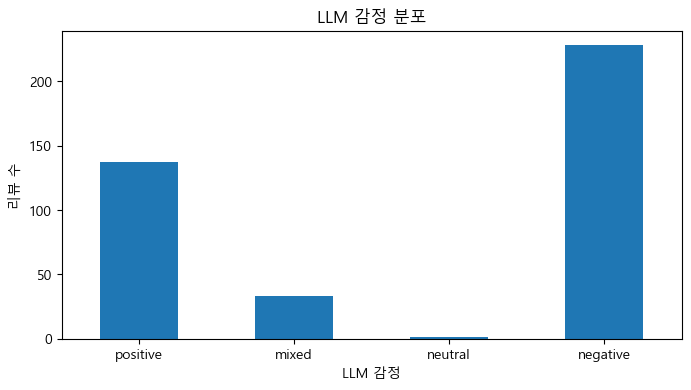

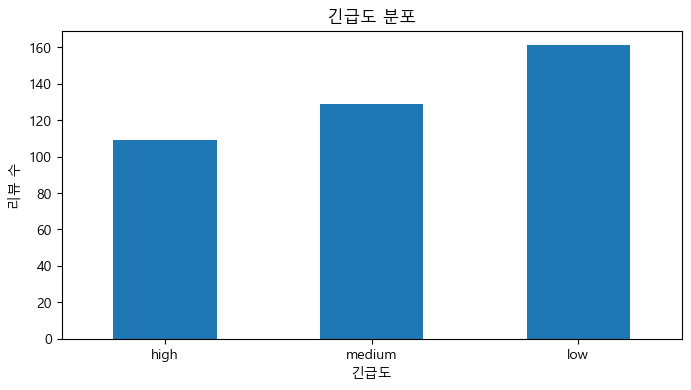

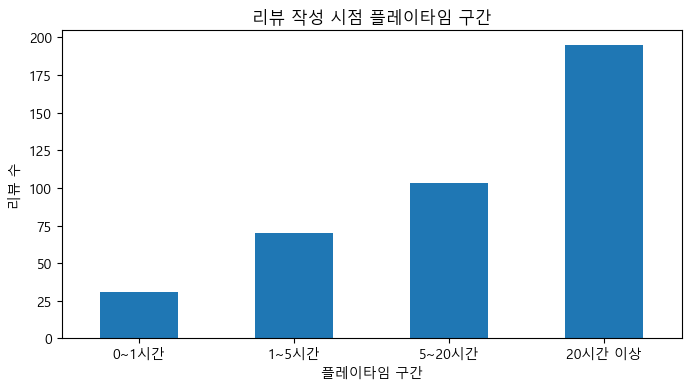

In [8]:
# ============================================================
# 4-1. 기본 분포 시각화
# ============================================================

if "llm_sentiment" in df_game.columns:
    sentiment_order = ["positive", "mixed", "neutral", "negative"]
    sentiment_counts = df_game["llm_sentiment"].value_counts().reindex(sentiment_order).dropna()

    ax = sentiment_counts.plot(kind="bar", figsize=(8, 4))
    ax.set_title("LLM 감정 분포")
    ax.set_xlabel("LLM 감정")
    ax.set_ylabel("리뷰 수")
    plt.xticks(rotation=0)
    plt.show()

if "urgency" in df_game.columns:
    urgency_order = ["high", "medium", "low"]
    urgency_counts = df_game["urgency"].value_counts().reindex(urgency_order).dropna()

    ax = urgency_counts.plot(kind="bar", figsize=(8, 4))
    ax.set_title("긴급도 분포")
    ax.set_xlabel("긴급도")
    ax.set_ylabel("리뷰 수")
    plt.xticks(rotation=0)
    plt.show()

if "playtime_bin" in df_game.columns:
    playtime_counts = df_game["playtime_bin"].value_counts().reindex(PLAYTIME_LABELS).dropna()

    ax = playtime_counts.plot(kind="bar", figsize=(8, 4))
    ax.set_title("리뷰 작성 시점 플레이타임 구간")
    ax.set_xlabel("플레이타임 구간")
    ax.set_ylabel("리뷰 수")
    plt.xticks(rotation=0)
    plt.show()


# 5. 출시 후 구간별 반응 변화

출시 후 분석에서는 단순 전체 평균보다 **시간에 따른 반응 변화**가 중요하다.

예를 들어 출시 초반에는 조작, 튜토리얼, 최적화 문제가 많이 나오고, 시간이 지난 뒤에는 콘텐츠 분량, 반복성, 밸런스 문제가 더 크게 나타날 수 있다.


,release_period,review_count,steam_positive_rate,llm_positive_rate,llm_negative_mixed_rate,high_urgency_rate,avg_playtime_hours,median_playtime_hours
0,D0-D30,92,0.402174,0.402174,0.597826,0.304348,22.307246,15.533333
2,D31-D90,118,0.449153,0.432203,0.567797,0.262712,25.264548,22.241667
3,D91-D180,79,0.303797,0.265823,0.721519,0.240506,18.416456,11.366667
1,D181+,110,0.281818,0.254545,0.745455,0.281818,28.480000,26.525000


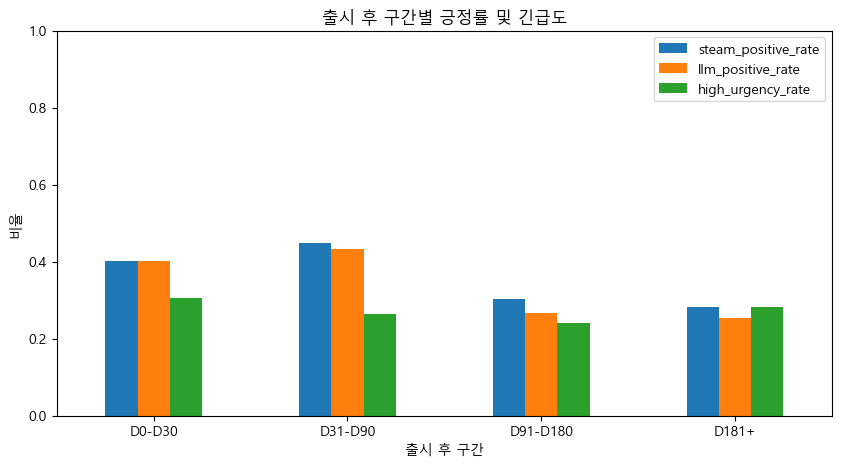

In [9]:
# ============================================================
# 5. 출시 후 구간별 반응 변화
# ============================================================

def sort_period_table(df, period_col="release_period"):
    result = df.copy()
    result["_period_order"] = result[period_col].apply(lambda x: PERIOD_ORDER.index(x) if x in PERIOD_ORDER else 999)
    result = result.sort_values(["_period_order", period_col]).drop(columns="_period_order")
    return result

period_summary = (
    df_game
    .groupby("release_period", dropna=False)
    .agg(
        review_count=("recommendationid", "count"),
        steam_positive_rate=("steam_label_text", lambda s: s.eq("positive").mean()),
        llm_positive_rate=("llm_sentiment", lambda s: s.eq("positive").mean()),
        llm_negative_mixed_rate=("llm_sentiment", lambda s: s.isin(["negative", "mixed"]).mean()),
        high_urgency_rate=("urgency", lambda s: s.eq("high").mean()),
        avg_playtime_hours=("playtime_at_review_hours", "mean"),
        median_playtime_hours=("playtime_at_review_hours", "median"),
    )
    .reset_index()
)

period_summary = sort_period_table(period_summary)

display(period_summary)

if not period_summary.empty:
    plot_df = period_summary.set_index("release_period")[["steam_positive_rate", "llm_positive_rate", "high_urgency_rate"]]

    ax = plot_df.plot(kind="bar", figsize=(10, 5))
    ax.set_title("출시 후 구간별 긍정률 및 긴급도")
    ax.set_xlabel("출시 후 구간")
    ax.set_ylabel("비율")
    plt.xticks(rotation=0)
    plt.ylim(0, 1)
    plt.show()


,days_from_release,review_count,steam_positive_rate,high_urgency_rate
0,0,2,0.000000,0.000000
1,1,2,0.500000,0.000000
2,2,2,1.000000,0.000000
3,3,1,0.000000,0.000000
4,4,6,0.333333,0.500000
5,5,4,0.750000,0.000000
6,6,6,0.166667,0.166667
7,7,3,0.666667,0.333333
8,8,5,0.600000,0.200000
9,9,1,0.000000,1.000000


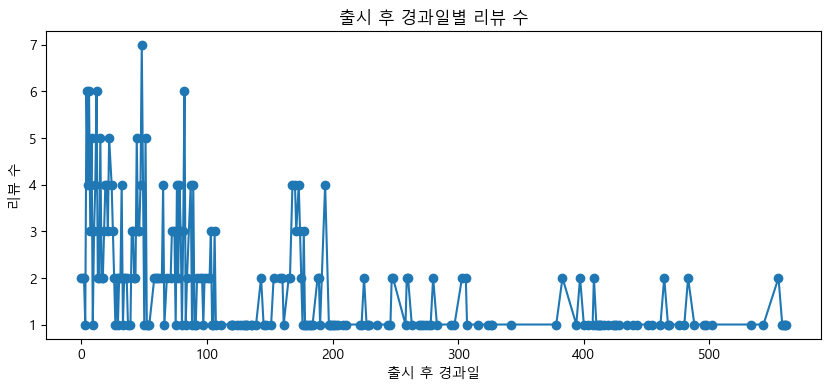

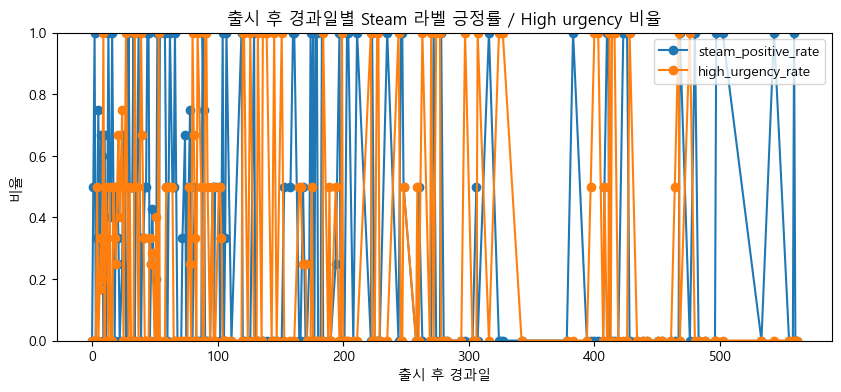

In [10]:
# ============================================================
# 5-1. 경과일별 리뷰 수와 반응 추세
# ============================================================

if "days_from_release" in df_game.columns and df_game["days_from_release"].notna().any():
    daily_summary = (
        df_game
        .dropna(subset=["days_from_release"])
        .assign(days_from_release=lambda d: d["days_from_release"].astype(int))
        .groupby("days_from_release")
        .agg(
            review_count=("recommendationid", "count"),
            steam_positive_rate=("steam_label_text", lambda s: s.eq("positive").mean()),
            high_urgency_rate=("urgency", lambda s: s.eq("high").mean()),
        )
        .reset_index()
        .sort_values("days_from_release")
    )

    display(daily_summary.head(30))

    if len(daily_summary) >= 2:
        ax = daily_summary.plot(
            x="days_from_release",
            y="review_count",
            kind="line",
            marker="o",
            figsize=(10, 4),
            legend=False
        )
        ax.set_title("출시 후 경과일별 리뷰 수")
        ax.set_xlabel("출시 후 경과일")
        ax.set_ylabel("리뷰 수")
        plt.show()

        ax = daily_summary.plot(
            x="days_from_release",
            y=["steam_positive_rate", "high_urgency_rate"],
            kind="line",
            marker="o",
            figsize=(10, 4)
        )
        ax.set_title("출시 후 경과일별 Steam 라벨 긍정률 / High urgency 비율")
        ax.set_xlabel("출시 후 경과일")
        ax.set_ylabel("비율")
        plt.ylim(0, 1)
        plt.show()
    else:
        print("경과일 종류가 1개라서 일자별 선 그래프는 생략합니다.")
else:
    print("days_from_release 컬럼이 없거나 비어 있어 경과일별 분석을 생략합니다.")


# 6. Steam 라벨과 LLM 감정 비교

Steam 추천/비추천 라벨과 LLM이 리뷰 본문에서 해석한 감정은 항상 일치하지 않는다.  
예를 들어 Steam에서는 추천 리뷰이지만, 본문에는 불편함이나 개선 요구가 함께 들어 있을 수 있다.

따라서 이 섹션에서는 Steam 라벨과 LLM 감정의 차이를 확인하여, 단순 추천 여부만으로 놓칠 수 있는 개선 요구를 살펴본다.


In [11]:
# ============================================================
# 6. Steam 라벨과 LLM 감정 비교
# ============================================================

steam_llm_crosstab = pd.crosstab(
    df_game["steam_label_text"],
    df_game["llm_sentiment"],
    margins=True
)

display(steam_llm_crosstab)

positive_but_not_positive = df_game[
    (df_game["steam_label_text"].eq("positive")) &
    (~df_game["llm_sentiment"].eq("positive"))
].copy()

negative_but_not_negative = df_game[
    (df_game["steam_label_text"].eq("negative")) &
    (~df_game["llm_sentiment"].eq("negative"))
].copy()

label_gap_summary = pd.DataFrame({
    "항목": [
        "Steam은 긍정이지만 LLM은 긍정이 아닌 리뷰",
        "Steam은 부정이지만 LLM은 부정이 아닌 리뷰",
    ],
    "리뷰 수": [
        len(positive_but_not_positive),
        len(negative_but_not_negative),
    ],
    "해석": [
        "게임을 추천하지만 불편함이나 개선 요구를 함께 말한 리뷰",
        "비추천이지만 일부 장점 또는 혼합 감정이 포함된 리뷰",
    ]
})

display(label_gap_summary)

review_cols = [
    "recommendationid",
    "review_datetime",
    "release_period",
    "playtime_at_review_hours",
    "steam_label_text",
    "llm_sentiment",
    "primary_issue",
    "urgency",
    "summary",
    "suggested_action",
]

print("Steam 긍정 리뷰 안의 개선 요구 예시")
display(positive_but_not_positive[[c for c in review_cols if c in positive_but_not_positive.columns]].head(10))


llm_sentiment,mixed,negative,neutral,positive,All
steam_label_text,,,,,
negative,26,228,0,0,254
positive,7,0,1,137,145
All,33,228,1,137,399


,항목,리뷰 수,해석
0,Steam은 긍정이지만 LLM은 긍정이 아닌 리뷰,8,게임을 추천하지만 불편함이나 개선 요구를 함께 말한 리뷰
1,Steam은 부정이지만 LLM은 부정이 아닌 리뷰,26,비추천이지만 일부 장점 또는 혼합 감정이 포함된 리뷰


Steam 긍정 리뷰 안의 개선 요구 예시


,recommendationid,review_datetime,release_period,playtime_at_review_hours,steam_label_text,llm_sentiment,primary_issue,urgency,summary,suggested_action
108,211991128,2025-11-30 16:22:25,D181+,40.900000,positive,mixed,story,medium,"게임의 전반적인 분위기와 메커니즘은 훌륭하나, 중요한 선택지 이후의 서사적 개연성과 경로 설계가 부족하여 몰입을 방해함.","중요한 분기점에서의 서사적 개연성을 보완하고, 플레이어의 선택이 결과에 미치는 영향에 대한 가이드를 개선하여 몰입감을 높일 필요가 있음."
161,224244318,2026-04-27 22:18:17,D181+,4.233333,positive,mixed,gameplay_loop,medium,"게임의 분위기와 아트 스타일은 훌륭하나, 전투 시스템이 취향에 맞지 않아 플레이를 지속하기 어려움.","전투 시스템의 타격감이나 조작 반응성을 개선하고, 튜토리얼을 보강하여 전투의 재미를 더 명확하게 전달할 필요가 있음."
197,193739882,2025-04-27 21:55:08,D181+,51.416667,positive,mixed,balance,medium,"고전적인 재미는 있으나 밸런스 문제, 불편한 조준 시스템, 불친절한 퀘스트 안내로 인해 후반부 플레이 경험이 다소 부정적임.","인간형 적과의 전투 밸런스를 재검토하고, 방향성 방어 시 자동 조준으로 인한 불편함을 개선하기 위해 조준 보정 옵션 토글 기능을 추가하는 것을 고려하세요. 또한 퀘스트 가이드라인을 보완하세요."
219,191094888,2025-03-24 19:05:26,D91-D180,26.500000,positive,mixed,story,medium,"전투와 세계관은 훌륭하나, 메인 스토리의 선택권 부족과 강제적인 서사 전개 방식이 아쉬움. 사이드 퀘스트의 자유도는 높음.","메인 스토리의 선택권 부족과 특정 강제적인 서사 전개에 대한 불만이 있으므로, 향후 업데이트나 차기작에서 메인 퀘스트의 분기점과 플레이어의 선택이 결과에 미치는 영향을 강화하는 방안을 고려하십시오."
296,192608815,2025-04-12 20:29:18,D91-D180,43.533333,positive,mixed,balance,medium,"전투와 스토리는 훌륭하나, 후반부 빌드 다양성 부족과 특정 무기 쏠림 현상, 강제적인 스토리 선택지에 대한 아쉬움이 있음.",무기 간 밸런스 조정 및 고유 스킬/효과를 강화하여 빌드 다양성을 확보하세요. 강제적인 스토리 분기점에 대해 플레이어의 선택권을 넓히는 방안을 검토하세요.
299,183214995,2024-12-20 18:19:50,D31-D90,22.483333,positive,mixed,gameplay_loop,medium,전반적인 게임성은 훌륭하나 후반부로 갈수록 퀘스트 안내가 불친절하고 이동 편의성이 떨어짐.,"후반부 퀘스트 가이드 및 내비게이션 개선, 점프 기능 부재로 인한 이동 불편함을 해소할 수 있는 지형 설계 보완 검토."
341,184840931,2025-01-05 14:47:59,D31-D90,32.716667,positive,mixed,story,medium,"전반적으로 게임성과 전투, 성장은 매우 만족스러우나 3막의 스토리와 NPC의 깊이, 음악의 다양성 부족에 아쉬움을 표함.","3막의 스토리 전개와 NPC 서사를 보강하고, 기존의 훌륭한 사운드트랙에 추가 곡을 업데이트하여 음악적 다양성을 확보하는 것을 고려하십시오."
373,192169878,2025-04-06 20:25:30,D91-D180,3.333333,positive,neutral,gameplay_loop,low,"게임의 매력은 이해하지만, 플레이어를 계속 붙잡아둘 만한 중독성 있는 요소가 부족하다고 느낌.",초반 몰입도를 높일 수 있는 핵심 게임플레이 루프나 보상 체계를 점검하여 플레이어의 지속적인 흥미를 유도할 필요가 있음.


# 7. 유저가 좋아한 요소 분석

이 섹션에서는 유저가 긍정적으로 언급한 요소를 확인한다.  
단, `positive_praise`는 “재밌다”, “좋다”처럼 전반적 만족 표현에 가까워 구체적인 운영 전략으로 연결하기 어렵다.

따라서 강점 분석에서는 `positive_praise`를 제외하고, 그래픽/사운드, 콘텐츠, 조작감, 난이도처럼 실제 유지·강화 전략으로 연결 가능한 태그를 중심으로 확인한다.


,항목,값
0,positive_praise 제외 리뷰 수,167
1,positive_praise 제외 태그 수,167


,tag_category,issue_name_kor,positive_tag_count,affected_review_count,avg_playtime_hours,median_playtime_hours,representative_evidence
3,gameplay_loop,게임플레이 루프,12,12,29.975000,29.166667,"Combat system feels fresh, yet simple. / Great quests, an interesting search system, an innovative health system. / ..."
7,story,스토리,8,8,39.885417,38.650000,story was surprisingly good / has a great story / The story is solid. It is grim and feels complete.
2,difficulty,난이도,6,6,40.225000,26.775000,"tough but fair, you'll find things you can't defeat early on. / appreciated the level of challenge in the early game..."
4,graphics_audio,그래픽/사운드,6,6,20.263889,20.133333,I did enjoy the art style and music. those were pretty good. / art style - music - sound design are good quality / T...
0,content_volume,콘텐츠 분량,2,2,48.833333,48.833333,"new stuff you'll be finding on each play through / whole world is gorgeous, there are multiple secret areas everywhere"
6,price_value,가격/가치,2,2,67.983333,67.983333,Definitly worth its price! / the asking price is fair
1,developer_communication,개발사 소통,1,1,11.316667,11.316667,The devs edited my save file to correct this.
5,performance,성능,1,1,45.833333,45.833333,Running smoothly on steam deck
8,translation_localization,번역/현지화,1,1,31.116667,31.116667,If youre german: GET THE GERMAN SPRACHAUSGABE MANN!!1
9,ui_ux,UI/UX,1,1,52.333333,52.333333,text enlargement settings made reading easy on Steam Deck


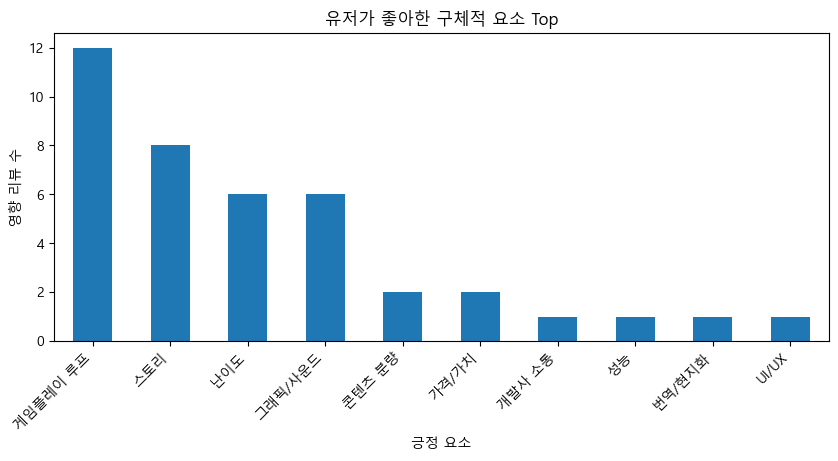

In [12]:
# ============================================================
# 7. 긍정 강점 분석
# ============================================================

pos_tags_all = df_game_tags[df_game_tags["tag_sentiment"].eq("positive")].copy()
positive_praise_tags = pos_tags_all[pos_tags_all["tag_category"].eq("positive_praise")].copy()

# positive_praise는 전반적 만족 표현이므로 구체적 강점 분석에서는 제외
pos_tags = pos_tags_all[~pos_tags_all["tag_category"].eq("positive_praise")].copy()

positive_praise_overview = pd.DataFrame({
    "항목": ["positive_praise 제외 리뷰 수", "positive_praise 제외 태그 수"],
    "값": [positive_praise_tags["recommendationid"].nunique(), len(positive_praise_tags)]
})

display(positive_praise_overview)

if pos_tags.empty:
    positive_strength_summary = pd.DataFrame()
    print("positive_praise를 제외하면 구체적인 긍정 태그가 없습니다.")
else:
    positive_strength_summary = (
        pos_tags
        .groupby(["tag_category", "issue_name_kor"], dropna=False)
        .agg(
            positive_tag_count=("tag_category", "count"),
            affected_review_count=("recommendationid", "nunique"),
            avg_playtime_hours=("playtime_at_review_hours", "mean"),
            median_playtime_hours=("playtime_at_review_hours", "median"),
            representative_evidence=("tag_evidence", lambda s: " / ".join(s.dropna().astype(str).head(3))),
        )
        .reset_index()
        .sort_values(["affected_review_count", "positive_tag_count"], ascending=False)
    )

    display(positive_strength_summary.head(TOP_N))

    ax = positive_strength_summary.head(TOP_N).set_index("issue_name_kor")["affected_review_count"].plot(
        kind="bar",
        figsize=(10, 4)
    )
    ax.set_title("유저가 좋아한 구체적 요소 Top")
    ax.set_xlabel("긍정 요소")
    ax.set_ylabel("영향 리뷰 수")
    plt.xticks(rotation=45, ha="right")
    plt.show()


# 8. 유저가 불만을 가진 요소 분석

출시 후 분석의 핵심은 **부정 리뷰에서 반복되는 문제를 찾는 것**이다.

여기서는 부정 태그를 기준으로 다음을 함께 확인한다.

| 항목 | 의미 |
|---|---|
| 부정 태그 수 | 해당 이슈가 얼마나 자주 언급되었는지 |
| 영향 리뷰 수 | 몇 개의 리뷰에서 이 문제가 나타났는지 |
| High urgency 리뷰 수 | 빠른 대응이 필요한 리뷰가 얼마나 있는지 |
| 평균 플레이타임 | 초반 이탈 문제인지, 누적 불만인지 |
| 대표 근거 | 실제 리뷰에서 나온 표현 |


,tag_category,issue_name_kor,negative_tag_count,affected_review_count,high_urgency_review_count,medium_urgency_review_count,short_exit_review_count,avg_playtime_hours,median_playtime_hours,total_votes_up,representative_evidence
7,gameplay_loop,게임플레이 루프,150,140,69,73,7,19.085778,11.208333,1238.0,"Quests are ludicrously hamfisted, quest logic is inconsistent / Unrealistic amounts of roaming for nothing worthy re..."
14,story,스토리,94,93,33,49,8,23.411702,22.541667,1019.0,"characters are singular and one-dimensional, dialogue is awful, prose is sloppy and fake / the writing is so simple ..."
0,balance,밸런스,61,61,37,24,0,28.658197,23.866667,524.0,Combat is probably the worst as its just a stat check. / Enemies that run around half naked have 10x more life than ...
6,difficulty,난이도,48,48,27,19,2,11.209028,8.066667,432.0,"If you want an unfair game, where enemies have 10 times the life than you have... outnumber you on every occasion? /..."
16,ui_ux,UI/UX,46,46,24,20,8,16.189130,9.908333,395.0,in-game map is illegible and unhelpful / not be able to pick up items with a weapon out / 인벤토리 아이콘 식별이 어려움
3,control,조작감,34,34,25,7,6,17.559804,5.941667,362.0,"combat is...terrible, like from the worst games I've ever played, the timing's all weird / hitboxes don't make sense..."
9,other,기타,34,33,6,7,7,9.939216,4.066667,688.0,"lock picking mechanics are unclear / souls-like 태그와 실제 게임 플레이 방식(적 리스폰 없음, 세이브 로드 방식)의 괴리감 지적 / 리뷰 내용이 게임의 구체적인 기능이나..."
12,progression_grind,성장/반복 노가다,27,26,13,14,0,25.441975,20.816667,295.0,Lots of progress locked behind questing chains. / leveling system requires finding specific NPCs for each skill / ne...
8,graphics_audio,그래픽/사운드,20,20,5,10,4,11.357500,5.958333,104.0,color palette hinders exploration / clunky sound design / color palette and overly pixelated graphics make for a dif...
2,content_volume,콘텐츠 분량,12,12,4,8,1,27.236111,28.158333,116.0,"very little sense of danger or exploration / 90% of the map seen by 10-15h, later areas are repetitive / no magic or..."


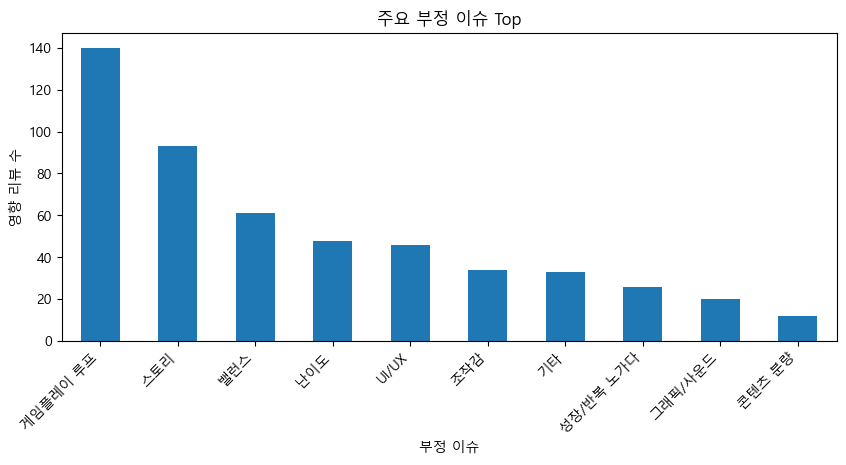

In [13]:
# ============================================================
# 8. 부정 이슈 분석
# ============================================================

neg_tags = df_game_tags[df_game_tags["tag_sentiment"].eq("negative")].copy()

if neg_tags.empty:
    negative_issue_summary = pd.DataFrame()
    print("부정 태그가 없습니다.")
else:
    negative_issue_summary = (
        neg_tags
        .groupby(["tag_category", "issue_name_kor"], dropna=False)
        .agg(
            negative_tag_count=("tag_category", "count"),
            affected_review_count=("recommendationid", "nunique"),
            high_urgency_review_count=("urgency", lambda s: s.eq("high").sum()),
            medium_urgency_review_count=("urgency", lambda s: s.eq("medium").sum()),
            short_exit_review_count=("playtime_bin", lambda s: s.eq("0~1시간").sum()),
            avg_playtime_hours=("playtime_at_review_hours", "mean"),
            median_playtime_hours=("playtime_at_review_hours", "median"),
            total_votes_up=("votes_up", "sum") if "votes_up" in neg_tags.columns else ("recommendationid", "count"),
            representative_evidence=("tag_evidence", lambda s: " / ".join(s.dropna().astype(str).head(3))),
        )
        .reset_index()
    )

    negative_issue_summary = negative_issue_summary.sort_values(
        ["affected_review_count", "high_urgency_review_count", "negative_tag_count"],
        ascending=False
    )

    display(negative_issue_summary.head(TOP_N))

    ax = negative_issue_summary.head(TOP_N).set_index("issue_name_kor")["affected_review_count"].plot(
        kind="bar",
        figsize=(10, 4)
    )
    ax.set_title("주요 부정 이슈 Top")
    ax.set_xlabel("부정 이슈")
    ax.set_ylabel("영향 리뷰 수")
    plt.xticks(rotation=45, ha="right")
    plt.show()


# 9. 플레이타임별 부정 원인

같은 부정 리뷰라도 플레이타임에 따라 의미가 다르다.

| 플레이타임 | 해석 |
|---|---|
| 0~1시간 | 첫인상, 튜토리얼, 조작, 최적화, 기대 불일치 문제 |
| 1~5시간 | 초반 플레이 경험, 반복성, 난이도, 진행 문제 |
| 5~20시간 | 중반 콘텐츠, 밸런스, 피로도, 버그 누적 |
| 20시간 이상 | 장기 플레이 유저의 후반 콘텐츠, 운영, 업데이트 불만 |


issue_name_kor,게임플레이 루프,스토리,밸런스,난이도,UI/UX,조작감,기타,성장/반복 노가다,그래픽/사운드,콘텐츠 분량
playtime_bin,,,,,,,,,,
0~1시간,7,8,0,2,8,6,7,0,4,1
1~5시간,38,15,9,16,11,11,12,5,6,2
5~20시간,55,22,18,22,12,3,10,7,6,2
20시간 이상,50,49,34,8,15,14,5,15,4,7


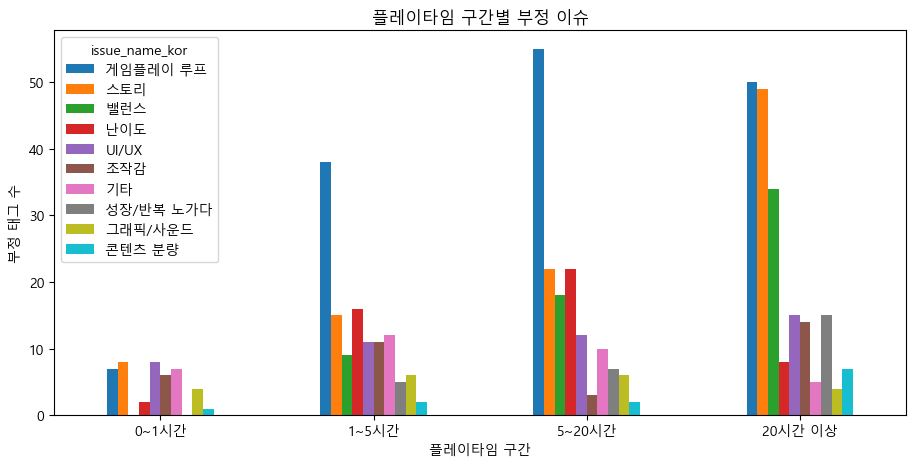

In [14]:
# ============================================================
# 9. 플레이타임별 부정 원인
# ============================================================

if neg_tags.empty:
    playtime_issue_table = pd.DataFrame()
    print("부정 태그가 없어 플레이타임별 부정 원인 분석을 생략합니다.")
else:
    playtime_issue_table = pd.crosstab(
        neg_tags["playtime_bin"],
        neg_tags["issue_name_kor"]
    )

    # 전체 빈도가 높은 이슈만 보기 좋게 정렬
    top_issue_cols = playtime_issue_table.sum(axis=0).sort_values(ascending=False).head(TOP_N).index
    playtime_issue_table = playtime_issue_table.reindex(PLAYTIME_LABELS).fillna(0)
    playtime_issue_table = playtime_issue_table[top_issue_cols]

    display(playtime_issue_table)

    ax = playtime_issue_table.plot(kind="bar", figsize=(11, 5))
    ax.set_title("플레이타임 구간별 부정 이슈")
    ax.set_xlabel("플레이타임 구간")
    ax.set_ylabel("부정 태그 수")
    plt.xticks(rotation=0)
    plt.show()


# 10. 패치·운영 우선 검토 이슈

출시 후 분석의 최종 목적은 리뷰에서 반복적으로 나타난 문제를 정리하고, 개발사가 어떤 이슈를 먼저 확인해야 하는지 판단할 수 있도록 돕는 것이다.

본 보고서에서는 임의의 종합 점수를 만들지 않고, 다음 기준을 나누어 확인한다.

1. 여러 리뷰에서 반복적으로 언급된 이슈
2. LLM이 High urgency로 분류한 리뷰가 많은 이슈
3. 0~1시간 플레이타임 구간에서 나타난 초기 이탈 관련 이슈
4. 출시 초반 구간에서 집중적으로 나타난 이슈

긴급도는 별도 수식으로 계산한 값이 아니라, LLM이 리뷰 본문을 읽고 분류한 값이다.  
따라서 High urgency 비율은 절대적인 장애 지표가 아니라, 유저가 느낀 문제의 심각도를 비교하기 위한 보조 기준으로 해석한다.

| 긴급도 | 해석 |
|---|---|
| high | 게임 진행 방해, 반복적 버그, 저장 문제, 심각한 불편처럼 빠른 확인이 필요한 문제 |
| medium | 불편함은 있으나 즉시 치명적이라고 보기는 어려운 문제 |
| low | 취향 차이, 가벼운 개선 요청, 단순 아쉬움에 가까운 문제 |


In [15]:
# ============================================================
# 10. 패치·운영 우선 검토 이슈
# ============================================================

# 패치·운영 검토는 전체 태그 중에서
# 1) 부정 태그이거나
# 2) LLM 감정이 negative/mixed이거나
# 3) urgency가 high인 태그를 중심으로 확인한다.
# 단, positive_praise는 전반적 만족 표현이므로 패치 대상 이슈에서는 제외한다.

priority_base = df_game_tags.copy()

if priority_base.empty:
    issue_priority_summary = pd.DataFrame()
    issue_action_summary = pd.DataFrame()
    issue_priority_with_action = pd.DataFrame()
    patch_priority = pd.DataFrame()
    operation_suggestion_table = pd.DataFrame()
    top_issue_evidence = pd.DataFrame()
    print("분석할 이슈 태그가 없어 패치·운영 우선 검토 이슈 분석을 생략합니다.")
else:
    # ------------------------------------------------------------
    # 1) 분석용 플래그 생성
    # ------------------------------------------------------------
    priority_base["urgency"] = priority_base["urgency"].astype(str).str.lower().str.strip()
    priority_base["llm_sentiment"] = priority_base["llm_sentiment"].astype(str).str.lower().str.strip()
    priority_base["tag_sentiment"] = priority_base["tag_sentiment"].astype(str).str.lower().str.strip()
    priority_base["release_period"] = priority_base["release_period"].astype(str).str.upper().str.strip()

    priority_base["is_negative_tag"] = priority_base["tag_sentiment"].eq("negative")
    priority_base["is_negative_or_mixed_review"] = priority_base["llm_sentiment"].isin(["negative", "mixed"])
    priority_base["is_high_urgency"] = priority_base["urgency"].eq("high")
    priority_base["is_initial_period"] = priority_base["release_period"].isin(["D0-D7", "D8-D30", "D0-D30"])

    if "playtime_at_review_hours" in priority_base.columns:
        priority_base["is_early_exit"] = priority_base["playtime_at_review_hours"].le(1)
    else:
        priority_base["is_early_exit"] = False

    # 조건별 리뷰 수를 중복 없이 세기 위한 보조 컬럼
    priority_base["high_urgency_review_id"] = priority_base["recommendationid"].where(priority_base["is_high_urgency"])
    priority_base["early_exit_review_id"] = priority_base["recommendationid"].where(priority_base["is_early_exit"])
    priority_base["initial_period_review_id"] = priority_base["recommendationid"].where(priority_base["is_initial_period"])
    priority_base["negative_or_mixed_review_id"] = priority_base["recommendationid"].where(priority_base["is_negative_or_mixed_review"])

    # 패치·운영 검토 대상만 필터링
    patch_focus_tags = priority_base[
        (
            priority_base["is_negative_tag"]
            | priority_base["is_negative_or_mixed_review"]
            | priority_base["is_high_urgency"]
        )
        & (~priority_base["tag_category"].eq("positive_praise"))
    ].copy()

    if patch_focus_tags.empty:
        issue_priority_summary = pd.DataFrame()
        issue_action_summary = pd.DataFrame()
        issue_priority_with_action = pd.DataFrame()
        patch_priority = pd.DataFrame()
        operation_suggestion_table = pd.DataFrame()
        top_issue_evidence = pd.DataFrame()
        print("패치·운영 우선 검토 대상으로 볼 부정/혼합/High urgency 이슈가 없습니다.")
    else:
        # ------------------------------------------------------------
        # 2) 이슈별 반복성·긴급성·초기 이탈·출시 초반 집중도 집계
        # ------------------------------------------------------------
        issue_priority_summary = (
            patch_focus_tags
            .groupby(["tag_category", "issue_name_kor"], dropna=False)
            .agg(
                영향_리뷰_수=("recommendationid", "nunique"),
                이슈_태그_수=("tag_category", "size"),
                부정_태그_수=("is_negative_tag", "sum"),
                부정_혼합_리뷰_수=("negative_or_mixed_review_id", "nunique"),
                High_urgency_리뷰_수=("high_urgency_review_id", "nunique"),
                초기_이탈_리뷰_수=("early_exit_review_id", "nunique"),
                출시초기_리뷰_수=("initial_period_review_id", "nunique"),
                평균_플레이타임=("playtime_at_review_hours", "mean"),
                중앙값_플레이타임=("playtime_at_review_hours", "median"),
                유용함_투표_합계=("votes_up", "sum"),
                대표_근거=("tag_evidence", lambda s: " / ".join(s.dropna().astype(str).head(3))),
            )
            .reset_index()
        )

        issue_priority_summary["High_urgency_비율"] = (
            issue_priority_summary["High_urgency_리뷰_수"]
            / issue_priority_summary["영향_리뷰_수"]
            * 100
        ).round(1)

        issue_priority_summary["초기_이탈_비율"] = (
            issue_priority_summary["초기_이탈_리뷰_수"]
            / issue_priority_summary["영향_리뷰_수"]
            * 100
        ).round(1)

        issue_priority_summary["출시초기_비율"] = (
            issue_priority_summary["출시초기_리뷰_수"]
            / issue_priority_summary["영향_리뷰_수"]
            * 100
        ).round(1)

        issue_priority_summary["평균_플레이타임"] = issue_priority_summary["평균_플레이타임"].round(2)
        issue_priority_summary["중앙값_플레이타임"] = issue_priority_summary["중앙값_플레이타임"].round(2)
        issue_priority_summary["유용함_투표_합계"] = issue_priority_summary["유용함_투표_합계"].fillna(0).round(0).astype(int)

        # 임의 점수를 만들지 않고, 긴급성 → 반복성 → 초기 이탈 → 출시 초반 집중도 순으로 정렬
        issue_priority_summary = issue_priority_summary.sort_values(
            [
                "High_urgency_리뷰_수",
                "영향_리뷰_수",
                "초기_이탈_리뷰_수",
                "출시초기_리뷰_수",
                "부정_태그_수",
            ],
            ascending=False
        )

        print("10-1. 패치·운영 우선 검토 이슈 표")
        display(issue_priority_summary.head(TOP_N))

        # ------------------------------------------------------------
        # 3) suggested_action 연결
        # ------------------------------------------------------------
        action_base = df_game[["recommendationid", "suggested_action"]].drop_duplicates()

        action_tags = patch_focus_tags.merge(
            action_base,
            on="recommendationid",
            how="left"
        )

        urgency_rank = {"high": 0, "medium": 1, "low": 2}
        action_tags["_urgency_rank"] = action_tags["urgency"].map(urgency_rank).fillna(9)

        sort_cols = ["tag_category", "issue_name_kor", "_urgency_rank"]
        ascending = [True, True, True]

        if "votes_up" in action_tags.columns:
            sort_cols.append("votes_up")
            ascending.append(False)

        issue_action_summary = (
            action_tags
            .dropna(subset=["suggested_action"])
            .drop_duplicates(["tag_category", "issue_name_kor", "suggested_action"])
            .sort_values(sort_cols, ascending=ascending)
            .groupby(["tag_category", "issue_name_kor"], dropna=False)
            .head(3)
            .groupby(["tag_category", "issue_name_kor"], dropna=False)["suggested_action"]
            .apply(lambda s: " / ".join(s.dropna().astype(str)))
            .reset_index()
            .rename(columns={"suggested_action": "패치_운영_제안"})
        )

        issue_priority_with_action = issue_priority_summary.merge(
            issue_action_summary,
            on=["tag_category", "issue_name_kor"],
            how="left"
        )

        # ------------------------------------------------------------
        # 4) 대응 유형 분류
        # ------------------------------------------------------------
        immediate_check_categories = ["bug", "crash", "performance", "optimization", "save_progression"]
        short_term_categories = ["gameplay_loop", "difficulty", "control", "ui_ux", "balance", "price_value", "progression_grind"]
        long_term_categories = ["content_volume", "multiplayer_network", "developer_communication", "translation_localization", "story", "monetization", "other"]

        def classify_response_type(tag_category):
            if tag_category in immediate_check_categories:
                return "즉시 확인"
            if tag_category in short_term_categories:
                return "단기 개선"
            if tag_category in long_term_categories:
                return "장기 검토"
            return "검토 필요"

        response_recommendation = {
            "즉시 확인": "플레이 방해 요소, 저장 문제, 버그, 성능 문제를 먼저 재현·확인한다.",
            "단기 개선": "반복 플레이 구조, 난이도, 조작감, UI/UX처럼 경험 품질을 낮추는 요소를 개선한다.",
            "장기 검토": "콘텐츠 확장, 멀티플레이, 스토리 보강처럼 업데이트 로드맵 수준에서 검토한다.",
            "검토 필요": "리뷰 원문과 태그 근거를 추가 확인한 뒤 대응 방향을 정한다.",
        }

        issue_priority_with_action["대응_구분"] = issue_priority_with_action["tag_category"].apply(classify_response_type)
        issue_priority_with_action["제안_방향"] = issue_priority_with_action["대응_구분"].map(response_recommendation)

        # 뒤쪽 요약에서 사용할 이름
        patch_priority = issue_priority_with_action.copy()

        display_cols = [
            "대응_구분",
            "issue_name_kor",
            "영향_리뷰_수",
            "High_urgency_리뷰_수",
            "High_urgency_비율",
            "초기_이탈_리뷰_수",
            "출시초기_리뷰_수",
            "패치_운영_제안",
        ]

        print("10-2. 이슈별 패치·운영 제안")
        display(issue_priority_with_action[display_cols].head(TOP_N))

        operation_suggestion_table = (
            issue_priority_with_action
            .groupby("대응_구분", dropna=False)
            .agg(
                주요_이슈=("issue_name_kor", lambda s: ", ".join(s.dropna().astype(str).head(5))),
                이슈_수=("issue_name_kor", "count"),
                영향_리뷰_수_합계=("영향_리뷰_수", "sum"),
                High_urgency_리뷰_수_합계=("High_urgency_리뷰_수", "sum"),
                제안_방향=("제안_방향", "first"),
            )
            .reset_index()
        )

        response_order = {"즉시 확인": 0, "단기 개선": 1, "장기 검토": 2, "검토 필요": 3}
        operation_suggestion_table["_order"] = operation_suggestion_table["대응_구분"].map(response_order).fillna(99)
        operation_suggestion_table = operation_suggestion_table.sort_values("_order").drop(columns="_order")

        print("10-3. 대응 유형별 운영 제안")
        display(operation_suggestion_table)

        # 유지·강화 후보는 긍정 강점 분석 결과에서 별도로 확인
        if "positive_strength_summary" in globals() and not positive_strength_summary.empty:
            maintain_strength_table = positive_strength_summary[
                ["issue_name_kor", "affected_review_count", "positive_tag_count", "representative_evidence"]
            ].head(5).copy()
            maintain_strength_table = maintain_strength_table.rename(columns={
                "issue_name_kor": "유지_강화_후보",
                "affected_review_count": "영향_리뷰_수",
                "positive_tag_count": "긍정_태그_수",
                "representative_evidence": "대표_근거",
            })

            print("10-4. 유지·강화 후보")
            display(maintain_strength_table)
        else:
            maintain_strength_table = pd.DataFrame()

        # ------------------------------------------------------------
        # 5) 최상위 이슈의 실제 근거 문장 확인
        # ------------------------------------------------------------
        top_issue_category = issue_priority_summary.iloc[0]["tag_category"]
        top_issue_name = issue_priority_summary.iloc[0]["issue_name_kor"]

        evidence_sort_cols = ["is_high_urgency"]
        evidence_ascending = [False]
        if "votes_up" in patch_focus_tags.columns:
            evidence_sort_cols.append("votes_up")
            evidence_ascending.append(False)
        if "playtime_at_review_hours" in patch_focus_tags.columns:
            evidence_sort_cols.append("playtime_at_review_hours")
            evidence_ascending.append(True)

        top_issue_evidence = (
            patch_focus_tags[patch_focus_tags["tag_category"].eq(top_issue_category)]
            .sort_values(evidence_sort_cols, ascending=evidence_ascending)
            [
                [
                    "game_name",
                    "issue_name_kor",
                    "urgency",
                    "llm_sentiment",
                    "release_period",
                    "playtime_at_review_hours",
                    "tag_evidence",
                ]
            ]
            .head(5)
        )

        print(f"10-5. 대표 리뷰 근거 확인: {top_issue_name}")
        display(top_issue_evidence)


10-1. 패치·운영 우선 검토 이슈 표


,tag_category,issue_name_kor,영향_리뷰_수,이슈_태그_수,부정_태그_수,부정_혼합_리뷰_수,High_urgency_리뷰_수,초기_이탈_리뷰_수,출시초기_리뷰_수,평균_플레이타임,중앙값_플레이타임,유용함_투표_합계,대표_근거,High_urgency_비율,초기_이탈_비율,출시초기_비율
7,gameplay_loop,게임플레이 루프,146,157,150,139,65,7,23,19.58,12.77,1301,"Quests are ludicrously hamfisted, quest logic is inconsistent / Unrealistic amounts of roaming for nothing worthy re...",44.5,4.8,15.8
0,balance,밸런스,61,61,61,59,37,0,10,28.66,23.87,524,Combat is probably the worst as its just a stat check. / Enemies that run around half naked have 10x more life than ...,60.7,0.0,16.4
14,story,스토리,99,100,94,94,35,8,19,23.97,22.60,1091,"characters are singular and one-dimensional, dialogue is awful, prose is sloppy and fake / the writing is so simple ...",35.4,8.1,19.2
6,difficulty,난이도,49,49,48,48,27,2,10,11.26,8.07,434,"If you want an unfair game, where enemies have 10 times the life than you have... outnumber you on every occasion? /...",55.1,4.1,20.4
3,control,조작감,34,34,34,34,25,6,8,17.56,5.94,362,"combat is...terrible, like from the worst games I've ever played, the timing's all weird / hitboxes don't make sense...",73.5,17.6,23.5
16,ui_ux,UI/UX,46,46,46,43,24,8,10,16.19,9.91,395,in-game map is illegible and unhelpful / not be able to pick up items with a weapon out / 인벤토리 아이콘 식별이 어려움,52.2,17.4,21.7
12,progression_grind,성장/반복 노가다,26,27,27,25,13,0,7,25.44,20.82,295,Lots of progress locked behind questing chains. / leveling system requires finding specific NPCs for each skill / ne...,50.0,0.0,26.9
8,graphics_audio,그래픽/사운드,28,28,20,26,10,5,6,13.91,9.40,160,color palette hinders exploration / clunky sound design / I did enjoy the art style and music. those were pretty good.,35.7,17.9,21.4
1,bug,버그,9,9,9,9,9,0,2,22.69,22.08,58,when I die and text pops up saying I won / most of them are buggy af / Enemy hitboxes are wonky enough that coupled ...,100.0,0.0,22.2
9,other,기타,37,38,34,35,5,7,10,11.49,4.91,739,"lock picking mechanics are unclear / souls-like 태그와 실제 게임 플레이 방식(적 리스폰 없음, 세이브 로드 방식)의 괴리감 지적 / 리뷰 내용이 게임의 구체적인 기능이나...",13.5,18.9,27.0


10-2. 이슈별 패치·운영 제안


,대응_구분,issue_name_kor,영향_리뷰_수,High_urgency_리뷰_수,High_urgency_비율,초기_이탈_리뷰_수,출시초기_리뷰_수,패치_운영_제안
0,단기 개선,게임플레이 루프,146,65,44.5,7,23,"커뮤니티 관리 정책을 재검토하고, 유저와의 소통 시 전문적이고 정중한 태도를 유지할 것을 권장합니다. 또한 게임 내 반복적인 콘텐츠와 밸런스 문제에 대한 피드백을 수렴하여 개선을 고려하십시오. / 초반부 대사..."
1,단기 개선,밸런스,61,37,60.7,0,10,"회피 판정(i-frame)과 이동 거리를 조정하고, 지형 끼임 현상을 수정하세요. 또한, 플레이어와 적 간의 자원 관리 및 공격 밸런스를 재조정하여 불합리한 난이도를 완화해야 합니다. 이동 경로의 가시성을 개..."
2,장기 검토,스토리,99,35,35.4,8,19,"전투 밸런스(적의 기동성 및 자원 소모)를 재검토하고, 캐릭터 대사 및 성격의 다양성을 확보하여 서사의 단조로움을 개선하는 패치를 고려하십시오. / 초반부 대사 및 퀘스트 스크립트를 전면 재검토하고, 캐릭터의..."
3,단기 개선,난이도,49,27,55.1,2,10,"몬스터의 체력 수치를 하향 조정하거나, 플레이어의 공격력 성장 곡선을 재검토하여 전투의 템포를 개선할 필요가 있습니다. 다양한 공격 패턴을 추가하여 전투의 단조로움을 줄이세요. / 이동 편의성(빠른 이동) 추..."
4,단기 개선,조작감,34,25,73.5,6,8,"회피 판정(i-frame)과 이동 거리를 조정하고, 지형 끼임 현상을 수정하세요. 또한, 플레이어와 적 간의 자원 관리 및 공격 밸런스를 재조정하여 불합리한 난이도를 완화해야 합니다. 이동 경로의 가시성을 개..."
5,단기 개선,UI/UX,46,24,52.2,8,10,"회피 판정(i-frame)과 이동 거리를 조정하고, 지형 끼임 현상을 수정하세요. 또한, 플레이어와 적 간의 자원 관리 및 공격 밸런스를 재조정하여 불합리한 난이도를 완화해야 합니다. 이동 경로의 가시성을 개..."
6,단기 개선,성장/반복 노가다,26,13,50.0,0,7,"퀘스트 동선 최적화(빠른 이동 추가 등), 적 다양성 확보를 위한 신규 몬스터 추가, 장비 시스템의 깊이 개선(특수 효과 부여 등)을 통해 후반부 지루함을 해소할 필요가 있습니다. / 전투 밸런스(적의 대미지..."
7,검토 필요,그래픽/사운드,28,10,35.7,5,6,"시각적 가독성을 높이기 위한 대비(contrast) 설정 옵션 추가, 카메라 시점 및 캐릭터 중심 고정 옵션 제공, 그리고 이동 속도 조절 기능을 검토하여 접근성을 개선하세요. / 퀘스트 보상 획득 시점 조정..."
8,즉시 확인,버그,9,9,100.0,0,2,"특정 NPC에게 소지품을 강탈당한 후 히트박스가 비활성화되는 버그를 조사하고, 강탈 이벤트 이후 NPC의 상태와 상호작용 로직을 수정해야 합니다. / 적의 히트박스 판정 개선, 공격 활성 프레임 조정, 그리고..."
9,장기 검토,기타,37,5,13.5,7,10,"이동 편의성(빠른 이동) 추가, 퀘스트 가이드 개선, 그리고 보스전의 난이도 곡선과 가시성을 재검토하여 불합리한 경험을 줄이십시오. / 전투 밸런스(적 체력 및 즉사기) 재조정, 히트박스 시각화 개선, 레벨 ..."


10-3. 대응 유형별 운영 제안


,대응_구분,주요_이슈,이슈_수,영향_리뷰_수_합계,High_urgency_리뷰_수_합계,제안_방향
3,즉시 확인,"버그, 저장/진행, 크래시, 성능",4,18,17,"플레이 방해 요소, 저장 문제, 버그, 성능 문제를 먼저 재현·확인한다."
1,단기 개선,"게임플레이 루프, 밸런스, 난이도, 조작감, UI/UX",7,371,195,"반복 플레이 구조, 난이도, 조작감, UI/UX처럼 경험 품질을 낮추는 요소를 개선한다."
2,장기 검토,"스토리, 기타, 콘텐츠 분량, 개발사 소통, 번역/현지화",5,159,47,"콘텐츠 확장, 멀티플레이, 스토리 보강처럼 업데이트 로드맵 수준에서 검토한다."
0,검토 필요,그래픽/사운드,1,28,10,리뷰 원문과 태그 근거를 추가 확인한 뒤 대응 방향을 정한다.


10-4. 유지·강화 후보


,유지_강화_후보,영향_리뷰_수,긍정_태그_수,대표_근거
3,게임플레이 루프,12,12,"Combat system feels fresh, yet simple. / Great quests, an interesting search system, an innovative health system. / ..."
7,스토리,8,8,story was surprisingly good / has a great story / The story is solid. It is grim and feels complete.
2,난이도,6,6,"tough but fair, you'll find things you can't defeat early on. / appreciated the level of challenge in the early game..."
4,그래픽/사운드,6,6,I did enjoy the art style and music. those were pretty good. / art style - music - sound design are good quality / T...
0,콘텐츠 분량,2,2,"new stuff you'll be finding on each play through / whole world is gorgeous, there are multiple secret areas everywhere"


10-5. 대표 리뷰 근거 확인: 게임플레이 루프


,game_name,issue_name_kor,urgency,llm_sentiment,release_period,playtime_at_review_hours,tag_evidence
670,Drova - Forsaken Kin,게임플레이 루프,high,negative,D181+,53.316667,"ridden with padding, artificially elongating the playtime"
1,Drova - Forsaken Kin,게임플레이 루프,high,negative,D181+,0.983333,"Quests are ludicrously hamfisted, quest logic is inconsistent"
780,Drova - Forsaken Kin,게임플레이 루프,high,negative,D91-D180,54.566667,"Boring fetch quests, run back and forth, travel annoying"
500,Drova - Forsaken Kin,게임플레이 루프,high,negative,D91-D180,20.316667,Combat is slow and shallow. Enemies are either one-hit kills or kill you in one or two hits.
90,Drova - Forsaken Kin,게임플레이 루프,high,negative,D181+,33.966667,"no fast travel, no movement speed options, tedious backtracking"


## 10-1. 해석 방법

위 표는 “절대적인 패치 순위표”가 아니라, 패치 회의에서 먼저 확인할 후보 이슈를 정리한 것이다.

- `영향 리뷰 수`가 높으면 여러 유저가 반복적으로 언급한 문제일 가능성이 높다.
- `High urgency 리뷰 수`가 높으면 유저가 심각하게 느낀 문제일 가능성이 높다.
- `초기 이탈 리뷰 수`가 높으면 첫인상, 조작, 튜토리얼, 진입 장벽 문제와 연결될 수 있다.
- `출시초기 리뷰 수`가 높으면 출시 직후 평가 흐름에 영향을 줬을 가능성이 있다.

따라서 실제 패치 방향은 단일 순위로 결정하기보다, `즉시 확인`, `단기 개선`, `장기 검토`, `유지·강화`처럼 대응 유형으로 나누어 검토하는 것이 적절하다.


# 11. 대표 리뷰 요약 및 개선 제안 확인

정량 집계만으로는 실제 유저 불만의 맥락을 놓칠 수 있다.  
따라서 긴급도가 높거나 부정/혼합 감정으로 분류된 리뷰를 직접 확인한다.


In [16]:
# ============================================================
# 11. 대표 리뷰 요약 및 개선 제안
# ============================================================

urgency_rank = {"high": 0, "medium": 1, "low": 2}

representative_reviews = df_game[
    df_game["llm_sentiment"].isin(["negative", "mixed"]) | df_game["urgency"].eq("high")
].copy()

representative_reviews["_urgency_rank"] = representative_reviews["urgency"].map(urgency_rank).fillna(9)

sort_cols = ["_urgency_rank"]
if "votes_up" in representative_reviews.columns:
    sort_cols.append("votes_up")

representative_reviews = representative_reviews.sort_values(
    sort_cols,
    ascending=[True] + [False] * (len(sort_cols) - 1)
)

representative_cols = [
    "recommendationid",
    "review_datetime",
    "release_period",
    "playtime_at_review_hours",
    "steam_label_text",
    "llm_sentiment",
    "primary_issue",
    "urgency",
    "summary",
    "suggested_action",
]

display(representative_reviews[[c for c in representative_cols if c in representative_reviews.columns]].head(TOP_N))


,recommendationid,review_datetime,release_period,playtime_at_review_hours,steam_label_text,llm_sentiment,primary_issue,urgency,summary,suggested_action
288,209809668,2025-11-22 01:58:56,D181+,21.733333,negative,negative,control,high,"전투 시스템의 불합리함(스태미나, 회피, 적의 성능)과 이동을 방해하는 과도한 지형지물로 인해 게임이 매우 답답함.","회피 판정(i-frame)과 이동 거리를 조정하고, 지형 끼임 현상을 수정하세요. 또한, 플레이어와 적 간의 자원 관리 및 공격 밸런스를 재조정하여 불합리한 난이도를 완화해야 합니다. 이동 경로의 가시성을 개..."
71,177301646,2024-10-19 00:37:33,D0-D30,7.483333,negative,negative,control,high,전투 시스템의 불합리함(적의 기동성 우위)과 모든 캐릭터가 동일한 성격으로 묘사되는 서사의 단조로움에 대해 강한 불만을 표함.,"전투 밸런스(적의 기동성 및 자원 소모)를 재검토하고, 캐릭터 대사 및 성격의 다양성을 확보하여 서사의 단조로움을 개선하는 패치를 고려하십시오."
327,209630667,2025-11-19 16:08:10,D181+,53.316667,negative,negative,developer_communication,high,"개발진의 비전문적이고 공격적인 커뮤니티 대응을 비판하며, 게임의 콘텐츠 구성과 밸런스에 대해서도 부정적으로 평가함.","커뮤니티 관리 정책을 재검토하고, 유저와의 소통 시 전문적이고 정중한 태도를 유지할 것을 권장합니다. 또한 게임 내 반복적인 콘텐츠와 밸런스 문제에 대한 피드백을 수렴하여 개선을 고려하십시오."
0,201691334,2025-08-08 08:52:41,D181+,0.983333,negative,negative,story,high,대사와 캐릭터의 깊이가 부족하고 퀘스트 설계가 부자연스러워 몰입하기 어렵다는 비판입니다.,"초반부 대사 및 퀘스트 스크립트를 전면 재검토하고, 캐릭터의 동기와 반응이 논리적으로 연결되도록 서사 구조를 보강하세요. 특히 퀘스트 진행 중 플레이어의 행동이 세계관에 미치는 영향력을 더 세밀하게 묘사할 필..."
387,191880956,2025-04-03 15:01:24,D91-D180,54.566667,negative,negative,gameplay_loop,high,"초반 몰입감은 좋으나 반복적인 퀘스트, 의미 없는 스토리, 부족한 적 다양성, 깊이 없는 장비 시스템으로 인해 후반부로 갈수록 지루하고 실망스럽다는 평가입니다.","퀘스트 동선 최적화(빠른 이동 추가 등), 적 다양성 확보를 위한 신규 몬스터 추가, 장비 시스템의 깊이 개선(특수 효과 부여 등)을 통해 후반부 지루함을 해소할 필요가 있습니다."
246,189289923,2025-03-03 19:31:35,D91-D180,20.316667,negative,negative,balance,high,"스토리와 탐험은 좋으나, 전투의 불합리한 밸런스와 스킬 습득을 위한 과도한 제약이 게임 경험을 저해함.","전투 밸런스(적의 대미지 및 스태미나 시스템)를 재검토하고, 스킬 습득을 위한 NPC 탐색 및 퀘스트 의존도를 완화하여 플레이어의 성장 자유도를 높이는 방안을 고려하십시오."
268,178311227,2024-11-03 12:37:58,D0-D30,25.183333,negative,negative,story,high,"전투 시스템의 조작감이 투박하고, 캐릭터의 행동이 대화 선택지와 일치하지 않는 서사적 모순 때문에 몰입이 깨짐.","전투 시스템의 조작감(clunky) 개선을 위한 최적화가 필요하며, 대화 선택지와 캐릭터의 후속 행동 간의 괴리를 줄여 서사적 일관성을 강화해야 합니다."
41,203831342,2025-09-07 21:33:42,D181+,33.966667,negative,negative,gameplay_loop,high,"그래픽은 훌륭하나 이동 수단 부재로 인한 반복적인 이동의 피로감, 불편한 UI/UX, 스토리의 질적 문제를 비판함.","이동 속도 개선, 빠른 이동(Fast Travel) 시스템 도입, 환경 스캔 방식의 편의성 개선을 통해 반복적인 이동으로 인한 피로도를 줄여야 합니다."
310,191568375,2025-03-30 14:30:39,D91-D180,0.566667,negative,negative,ui_ux,high,"아트 스타일은 훌륭하나, 낮은 명암 대비와 카메라 시스템으로 인해 눈의 피로와 멀미를 유발하여 플레이가 어렵다는 의견입니다.","시각적 가독성을 높이기 위한 대비(contrast) 설정 옵션 추가, 카메라 시점 및 캐릭터 중심 고정 옵션 제공, 그리고 이동 속도 조절 기능을 검토하여 접근성을 개선하세요."
331,211270245,2025-11-27 21:01:13,D181+,51.666667,negative,negative,story,high,"게임의 전반적인 분위기는 매우 만족스러우나, 3장에서 플레이어의 이전 선택과 무관하게 강제되는 스토리 전개로 인해 몰입감이 크게 훼손됨.","플레이어의 이전 선택이 후반부 스토리 전개에 더 유의미하게 반영되도록 분기점을 재설계하거나, 강제적인 서사 진행에 대한 당위성을 보강하여 몰입감 저하를 방지할 것."


# 12. 보고서용 요약

아래 내용은 팀 노션이나 최종 보고서에 넣을 수 있는 요약 예시이다.  
숫자와 주요 이슈명은 현재 실행 결과를 확인한 뒤 최종 보고서에 맞게 한 번 더 점검한다.


# 13. 분석 한계 및 최종 정리

## 분석 한계

본 분석은 Steam 전체 리뷰가 아니라, LLM 분석 대상으로 선별된 리뷰 표본을 기준으로 한다.  
따라서 긍정률, 부정 이슈 비율, High urgency 비율은 전체 유저 반응의 절대값이라기보다, 분석 표본 안에서 확인된 경향으로 해석해야 한다.

또한 `urgency`, `summary`, `suggested_action`은 LLM이 리뷰 본문을 해석해 생성한 결과이므로, 실제 개발 우선순위를 확정하기 위한 기준이라기보다 패치 회의에서 참고할 수 있는 보조 지표로 활용하는 것이 적절하다.

마지막으로 `tag_evidence`는 리뷰에서 특정 이슈를 판단한 근거 문장 또는 표현이며, 번역·요약 과정에서 원문 전체 맥락이 일부 축약될 수 있다.

## 최종 정리

| 결과 | 활용 |
|---|---|
| 출시 후 반응 기본 요약 | 현재 게임의 반응 상태 설명 |
| 구간별 반응 변화 | 출시 초반/이후 반응 변화 확인 |
| 긍정 강점 분석 | 유지·강화해야 할 요소 제안 |
| 부정 이슈 분석 | 유저 불만 원인 정리 |
| 플레이타임별 부정 원인 | 초반 이탈/장기 불만 구분 |
| 패치·운영 우선 검토 이슈 | 개발사가 먼저 확인할 후보 이슈 제안 |
| 대응 유형별 운영 제안 | 즉시 확인/단기 개선/장기 검토/유지 강화로 대응 방향 정리 |
